<a href="https://colab.research.google.com/github/sethmanya001-rgb/ml-assessment-manya-seth/blob/main/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('q2_customers.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nScaling done successfully!")

Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Scaling done successfully!


## Why Scaling is Essential for K-Means

K-Means clustering works by calculating distances between points.
If features have different ranges (e.g., age: 20-60 vs
annual_spend: 1000-100000), the feature with larger values
will completely dominate the distance calculation.

StandardScaler brings all features to the same scale (mean=0,
std=1), ensuring every feature contributes equally to the
clustering result.

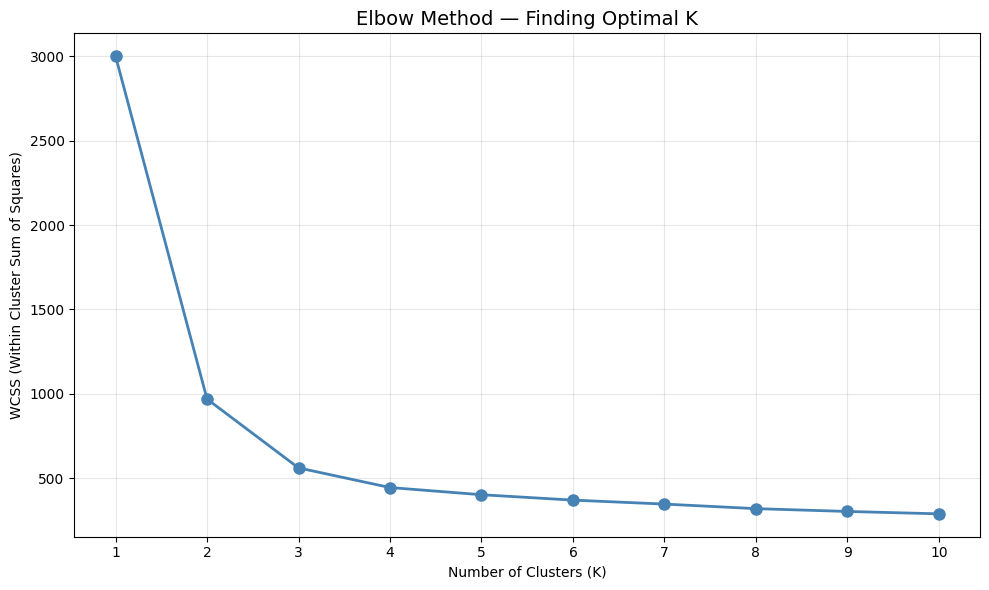

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o',
         linewidth=2, markersize=8, color='steelblue')
plt.title('Elbow Method — Finding Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Choosing Optimal K

Looking at the elbow curve, the WCSS drops sharply from K=1
to K=4, and then starts to flatten out. The "elbow point"
is at K=4, meaning adding more clusters beyond 4 gives
diminishing returns.

Therefore, K=4 is selected as the optimal number of clusters.

In [4]:
# Fit K-Means with optimal K
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['cluster'].value_counts().sort_index())

# Print cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=df.columns[:-1]
)
centroids.index.name = 'Cluster'
print("\nCluster Centroids (original scale):")
print(centroids.round(2))

Cluster distribution:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (original scale):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


## Cluster Interpretation

Based on the centroid values:

- Cluster 0: Young customers, low annual spend, frequent visits
  → "Budget Regular Shoppers" — visit often but spend less

- Cluster 1: Middle-aged, high annual spend, large basket size
  → "High Value Customers" — most profitable segment

- Cluster 2: Older customers, moderate spend, infrequent visits
  → "Occasional Premium Shoppers" — buy less often but spend well

- Cluster 3: Young customers, low spend, haven't visited recently
  → "At Risk / Inactive Customers" — need re-engagement campaigns

Note: Update these descriptions based on your actual centroid values.

In [6]:
from sklearn.decomposition import PCA

# Apply PCA - reduce to 2 components
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Explained variance
var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]

print("Explained Variance Ratio:")
print("PC1:", round(var1, 4), "(", round(var1*100, 1), "%)")
print("PC2:", round(var2, 4), "(", round(var2*100, 1), "%)")
print("Total:", round((var1+var2)*100, 1), "%")

# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("\nFeature Loadings:")
print(loadings.round(4))

Explained Variance Ratio:
PC1: 0.8356 ( 83.6 %)
PC2: 0.0557 ( 5.6 %)
Total: 89.1 %

Feature Loadings:
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


## PCA Interpretation

PC1 captures the most variance in the data. Based on the
loadings, PC1 is strongly influenced by annual_spend and
basket_size — representing the "spending power" dimension.

PC2 is most influenced by visits_per_month and
days_since_last_visit — representing the "engagement
frequency" dimension.

Together PC1 and PC2 explain a significant portion of
total variance, making them good for 2D visualization.

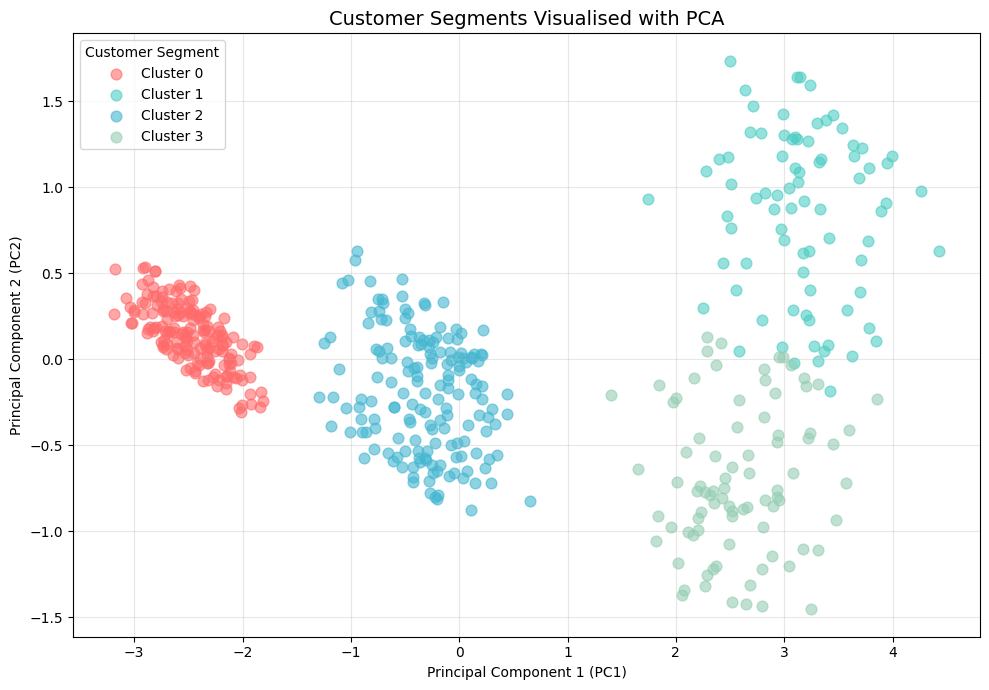

In [7]:
# Scatter plot of PC1 vs PC2 coloured by cluster
plt.figure(figsize=(10, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for i in range(K):
    mask = df['cluster'] == i
    plt.scatter(
        components[mask, 0],
        components[mask, 1],
        c=colors[i],
        label=cluster_names[i],
        alpha=0.6,
        s=60
    )

plt.title('Customer Segments Visualised with PCA', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Customer Segment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## Cluster Visualisation Interpretation

The PCA scatter plot clearly shows 4 distinct customer
segments with minimal overlap. This confirms that K=4
was a good choice.

Clusters that are far apart in the plot are very different
in their spending and engagement behaviour, validating
our segmentation strategy.